In [65]:
import os
import random
import numpy as np
import pandas as pd
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns
import gc 
import time
import copy
import math
from torchvision.transforms import RandAugment

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import torchinfo
from torchinfo import summary
from torch.utils.data import Dataset, DataLoader
from torch.utils.data import WeightedRandomSampler
from torchvision import transforms
from torchvision import models
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report, accuracy_score, f1_score, cohen_kappa_score, roc_auc_score, precision_score, recall_score
from PIL import Image

from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image

In [66]:

base_path = 'LungHist700_combined/data/'
csv_path = base_path + 'data.csv'
images_base = base_path + 'images/' 

batch_size = 32
num_epochs = 100
learning_rate = 3e-4
random_seed = 42

def seed_everything(seed):
    random.seed(seed)

    os.environ['PYTHONHASHSEED'] = str(seed)

    np.random.seed(seed)

    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

    torch.use_deterministic_algorithms(True)


def seed_worker(worker_id):

    worker_seed = torch.initial_seed() % 2**32

    np.random.seed(worker_seed)
    random.seed(worker_seed)

seed_everything(random_seed)

g = torch.Generator()
g.manual_seed(random_seed)


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Dispositivo em uso: {device}\n")

full_df = pd.read_csv(csv_path)
superclass_map = {'aca': 0, 'ssc': 1, 'scc': 1, 'nor': 2}
full_df['label'] = full_df['superclass'].map(superclass_map)

print("Dados carregados e mapeados com sucesso!")
print("Total de linhas:", len(full_df))
print("Colunas:", full_df.columns.tolist())
print("Exemplo das 5 primeiras linhas:\n", full_df.head())
print("Distribuição de resolução:\n", full_df['resolution'].value_counts())


def get_dataframe_no_loss(df_input):
    return df_input.sample(frac=1, random_state=random_seed).reset_index(drop=True)

print("Função de processamento de dados atualizada!")

Dispositivo em uso: cpu

Dados carregados e mapeados com sucesso!
Total de linhas: 691
Colunas: ['superclass', 'subclass', 'resolution', 'image_id', 'patient_id', 'label']
Exemplo das 5 primeiras linhas:
   superclass subclass resolution  image_id  patient_id  label
0        aca       bd        40x       901           1      0
1        aca       bd        40x       902           1      0
2        aca       bd        40x       903           1      0
3        aca       bd        40x       904           1      0
4        aca       bd        40x       905           1      0
Distribuição de resolução:
 resolution
20x    359
40x    332
Name: count, dtype: int64
Função de processamento de dados atualizada!


In [67]:
class LungHistDataset(Dataset):
    def __init__(self, dataframe, root_dir, transform=None):
        self.df = dataframe
        self.root_dir = root_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        superclass = row['superclass'] 
        image_id = row['image_id']
        resolution = row['resolution']
        subclass = row['subclass'] if not pd.isna(row['subclass']) else ""

        folder_name = superclass
        if superclass == 'scc':
            folder_name = 'ssc' 
        
        class_dir = os.path.join(self.root_dir, folder_name)

        potential_filenames = [
            f"{image_id}.jpg",                                      
            f"{superclass}_{subclass}_{resolution}_{image_id}.jpg", 
            f"{superclass}_{resolution}_{image_id}.jpg",            
            f"{image_id}.png",                                     
            f"{superclass}_{subclass}_{resolution}_{image_id}.png"
        ]
        
        img_path = None
        for fname in potential_filenames:
            full_path = os.path.join(class_dir, fname)
            if os.path.exists(full_path):
                img_path = full_path
                break
        
        if img_path is None and os.path.exists(class_dir):
            import glob
            search_pattern = os.path.join(class_dir, f"*{image_id}.*")
            found_files = glob.glob(search_pattern)
            if found_files:
                img_path = found_files[0]

        try:
            if img_path is None:
                raise FileNotFoundError(f"Imagem com ID {image_id} não encontrada em {class_dir}")
            image = Image.open(img_path).convert("RGB")
        except Exception as e:
            image = Image.new('RGB', (224, 224))
            
        label = row['label']
        if self.transform:
            image = self.transform(image)
        return image, label

print("Classe Dataset definida com sucesso!")

Classe Dataset definida com sucesso!


In [ ]:
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
    
  
    transforms.RandAugment(num_ops=2, magnitude=7),

    
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(15),

    transforms.ToTensor(),

   
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


val_test_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

print("RandAugment configurado com sucesso.")

✅ RandAugment configurado com sucesso.


/tmp/ipykernel_15648/98978159.py:56: MatplotlibDeprecationWarning: Auto-removal of overlapping axes is deprecated since 3.6 and will be removed two minor releases later; explicitly call ax.remove() as needed.
  plt.subplot(1, 6, i + 2)


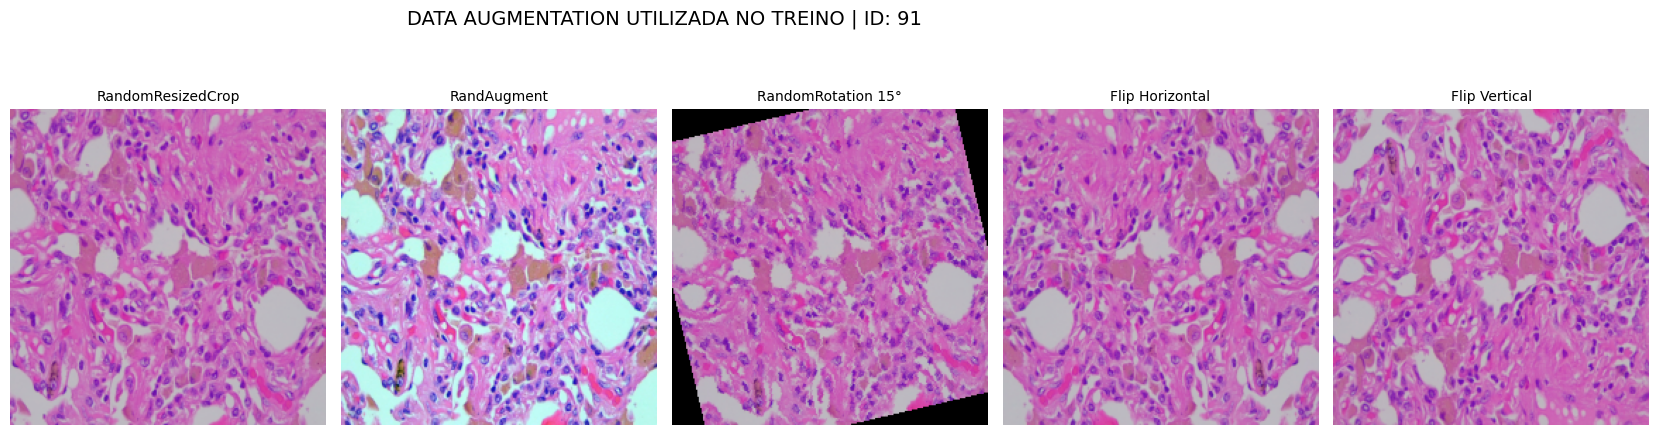

In [69]:
rand_idx = random.randint(0, len(full_df) - 1)

demo_ds = LungHistDataset(
    full_df,
    root_dir=images_base,
    transform=None
)

original_img, label_idx = demo_ds[rand_idx]

idx_to_class = {
    0: 'ACA',
    1: 'SCC',
    2: 'NOR'
}

class_name = idx_to_class[label_idx]

demo_augmentations = [
    ("RandomResizedCrop", transforms.RandomResizedCrop(
        224,
        scale=(0.8, 1.0)
    )),

    ("RandAugment", transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandAugment(num_ops=2, magnitude=7)
    ])),

    ("RandomRotation 15°", transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomRotation(15)
    ])),

    ("Flip Horizontal", transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomHorizontalFlip(p=1.0)
    ])),

    ("Flip Vertical", transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomVerticalFlip(p=1.0)
    ])),
]

plt.figure(figsize=(20, 5))

plt.subplot(1, 5, 1)
plt.imshow(original_img)
plt.title(f"ORIGINAL ({class_name})", fontweight='bold')
plt.axis('off')

for i, (name, transform_func) in enumerate(demo_augmentations):
    aug_img = transform_func(original_img)

    plt.subplot(1, 6, i + 2)
    plt.imshow(aug_img)
    plt.title(name, fontsize=10)
    plt.axis('off')

img_id = full_df.iloc[rand_idx]['image_id']

plt.suptitle(
    f"DATA AUGMENTATION UTILIZADA NO TREINO | ID: {img_id}",
    fontsize=14
)

plt.tight_layout()
plt.show()

In [70]:
# ====================== PARTE 6: FUNÇÃO DE ESTATÍSTICAS ======================
def print_stats_table(df_name, train_df, val_df, test_df):
    c_train = train_df['label'].value_counts().to_dict()
    c_val   = val_df['label'].value_counts().to_dict()
    c_test  = test_df['label'].value_counts().to_dict()
    idx_to_class = {0: 'ACA', 1: 'SCC', 2: 'NOR'}
    
    print(f"\nCONJUNTO DE DADOS: {df_name}")
    print("-" * 42)
    print(f"{'CLASSE':<8} | {'TREINO':<8} | {'VALIDAÇÃO':<8} | {'TESTE':<8}")
    print("-" * 42)
    for idx in range(3): 
        name = idx_to_class[idx]
        print(f"{name:<8} | {c_train.get(idx, 0):<8} | {c_val.get(idx, 0):<8} | {c_test.get(idx, 0):<8}")
    print("-" * 42 + "\n")

print("Função print_stats_table definida com sucesso!")

Função print_stats_table definida com sucesso!


In [71]:
def make_weighted_sampler(df_train, label_col='label', seed=42):

    class_counts = df_train[label_col].value_counts().sort_index().values

    # pesos inversos
    class_weights = 1.0 / class_counts

    sample_weights = [
        class_weights[label]
        for label in df_train[label_col]
    ]

    # generator fixo
    g = torch.Generator()
    g.manual_seed(seed)

    sampler = WeightedRandomSampler(
        weights=sample_weights,
        num_samples=len(sample_weights),
        replacement=True,
        generator=g
    )

    return sampler

print("Função make_weighted_sampler definida com sucesso!")

Função make_weighted_sampler definida com sucesso!


In [72]:

def get_reproducible_ids(df, resolution):

    if resolution == '20x':
        train_ids = [2,3,4,5,7,8,12,14,15,16,17,18,20,21,23,24,25,26,28,29,30,33,36,37,38,39,41,42,45]
        val_ids   = [1,6,27,32,44]
        test_ids  = [9,13,31,40]

    elif resolution == '40x':
        train_ids = [2,6,8,9,10,12,13,14,16,18,19,21,22,24,28,29,31,33,34,35,36,38,40,44]
        val_ids   = [1,4,17,26,30,37,45]
        test_ids  = [11,15,20,25,32,43]

    else:
        raise ValueError("Resolution deve ser '20x' ou '40x'")

    train_df = df[df['patient_id'].isin(train_ids)]
    val_df   = df[df['patient_id'].isin(val_ids)]
    test_df  = df[df['patient_id'].isin(test_ids)]

    return train_df, val_df, test_df



def process_resolution(res):

    print(f"\n====================== {res.upper()} ======================")

   
    df_res = full_df[
        (full_df['resolution'] == res) &
        (full_df['superclass'].isin(['aca', 'nor', 'scc']))
    ].reset_index(drop=True)

    print(f"Dataset {res}: {len(df_res)} imagens")

  
    df_res = get_dataframe_no_loss(df_res)

    
    train_df, val_df, test_df = get_reproducible_ids(df_res, res)

    
    train_df = train_df.reset_index(drop=True)
    val_df   = val_df.reset_index(drop=True)
    test_df  = test_df.reset_index(drop=True)

  
    print("\n📊 Classes por split:")
    for name, df_split in [("train", train_df), ("val", val_df), ("test", test_df)]:
        print(f"\n{name.upper()}")
        print(df_split["superclass"].value_counts())

    print("\n🔎 Verificação de leakage:")
    print("train ∩ val :", set(train_df['patient_id']) & set(val_df['patient_id']))
    print("train ∩ test:", set(train_df['patient_id']) & set(test_df['patient_id']))
    print("val ∩ test :", set(val_df['patient_id']) & set(test_df['patient_id']))

    train_sampler = make_weighted_sampler(train_df, label_col='label')

    train_ds = LungHistDataset(train_df, images_base, transform=train_transform)
    val_ds   = LungHistDataset(val_df,   images_base, transform=val_test_transform)
    test_ds  = LungHistDataset(test_df,  images_base, transform=val_test_transform)

    train_loader = DataLoader(
        train_ds,
        batch_size=batch_size,
        sampler=train_sampler,
        shuffle=False,
        num_workers=4,
        pin_memory=True,
        worker_init_fn=seed_worker,
        generator=g,
        persistent_workers=True
    )

    val_loader = DataLoader(
        val_ds,
        batch_size=batch_size,
        shuffle=False,
        num_workers=4,
        pin_memory=True,
        worker_init_fn=seed_worker,
        generator=g,
        persistent_workers=True
    )

    test_loader = DataLoader(
        test_ds,
        batch_size=batch_size,
        shuffle=False,
        num_workers=4,
        pin_memory=True,
        worker_init_fn=seed_worker,
        generator=g,
        persistent_workers=True
    )

    print_stats_table(f"{res.upper()} (SPLIT FIXO POR PACIENTE)", train_df, val_df, test_df)

    return train_loader, val_loader, test_loader



train_loader_20x, val_loader_20x, test_loader_20x = process_resolution('20x')
train_loader_40x, val_loader_40x, test_loader_40x = process_resolution('40x')


====================== 20X ======================
Dataset 20x: 359 imagens

📊 Classes por split:

TRAIN
superclass
aca    109
scc    102
nor     52
Name: count, dtype: int64

VAL
superclass
aca    19
scc    15
nor    14
Name: count, dtype: int64

TEST
superclass
nor    19
aca    18
scc    11
Name: count, dtype: int64

🔎 Verificação de leakage:
train ∩ val : set()
train ∩ test: set()
val ∩ test : set()

CONJUNTO DE DADOS: 20X (SPLIT FIXO POR PACIENTE)
------------------------------------------
CLASSE   | TREINO   | VALIDAÇÃO | TESTE   
------------------------------------------
ACA      | 109      | 19       | 18      
SCC      | 102      | 15       | 11      
NOR      | 52       | 14       | 19      
------------------------------------------


====================== 40X ======================
Dataset 40x: 332 imagens

📊 Classes por split:

TRAIN
superclass
aca    101
scc     96
nor     39
Name: count, dtype: int64

VAL
superclass
aca    16
scc    16
nor    14
Name: count, dtype: int6

In [74]:
def get_model(model_name, num_classes=3, feature_extract=True):
    model = None
    if model_name == 'resnet50':
        weights = models.ResNet50_Weights.DEFAULT
        model = models.resnet50(weights=weights)
        if feature_extract:
            for param in model.parameters(): param.requires_grad = False
        num_ftrs = model.fc.in_features
        model.fc = nn.Sequential(nn.Dropout(0.5), nn.Linear(num_ftrs, num_classes))

    elif model_name == 'efficientnet_b0':
        weights = models.EfficientNet_B0_Weights.DEFAULT
        model = models.efficientnet_b0(weights=weights)
        if feature_extract:
            for param in model.parameters(): param.requires_grad = False
        num_ftrs = model.classifier[1].in_features 
        model.classifier = nn.Sequential(nn.Dropout(0.3), nn.Linear(num_ftrs, num_classes))

    elif model_name == 'efficientnet_b3':
        weights = models.EfficientNet_B3_Weights.DEFAULT 
        model = models.efficientnet_b3(weights=weights)
        if feature_extract:
            for param in model.parameters(): param.requires_grad = False
        num_ftrs = model.classifier[1].in_features
        model.classifier = nn.Sequential(nn.Dropout(0.4), nn.Linear(num_ftrs, num_classes))
        
    elif model_name == 'densenet121':
        weights = models.DenseNet121_Weights.DEFAULT
        model = models.densenet121(weights=weights)
        if feature_extract:
            for param in model.parameters(): param.requires_grad = False
        num_ftrs = model.classifier.in_features
        model.classifier = nn.Sequential(nn.Dropout(0.5), nn.Linear(num_ftrs, num_classes))
    
    return model.to(device)

In [ ]:
#CONFG
def train_model(
    model,
    dataloaders,
    criterion,
    num_epochs=100,
    save_name='best_model.pth',
    model_name='MODEL',

    learning_rate=3e-4,
    weight_decay=1e-4,

    optimizer_name="adamw",
    scheduler_name="cosine",

    scheduler_step_size=10,
    scheduler_gamma=0.1,
    scheduler_t_max=35,
    min_learning_rate=1e-6,

    early_stopping_patience=20
):

    since = time.time()

    val_acc_history = []
    train_loss_history = []
    val_loss_history = []

    best_model_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0

    epochs_no_improve = 0

  

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=learning_rate,
        weight_decay=weight_decay
    )



    if scheduler_name == "cosine":
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
            optimizer,
            T_max=scheduler_t_max,
            eta_min=min_learning_rate
        )

    elif scheduler_name == "step":
        scheduler = torch.optim.lr_scheduler.StepLR(
            optimizer,
            step_size=scheduler_step_size,
            gamma=scheduler_gamma
        )

    elif scheduler_name == "plateau":
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer,
            mode='min',
            factor=scheduler_gamma,
            patience=5
        )

    else:
        scheduler = None

    print(f"\n🚀 START TRAINING {model_name}")
    print(f"🧠 Early Stopping patience = {early_stopping_patience}")

    
    for epoch in range(num_epochs):

        print(f'\nEpoch {epoch+1:02d}/{num_epochs}')

        epoch_val_loss = None
        improved = False

        for phase in ['train', 'val']:

            if phase == 'train':
                model.train()
            else:
                model.eval()

            running_loss = 0.0
            running_corrects = 0

            for inputs, labels in dataloaders[phase]:

                inputs = inputs.to(device)
                labels = labels.to(device)

                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == 'train'):

                    outputs = model(inputs)

                    loss = criterion(outputs, labels)

                    _, preds = torch.max(outputs, 1)

                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

            epoch_loss = running_loss / len(dataloaders[phase].dataset)

            epoch_acc = (
                running_corrects.double() /
                len(dataloaders[phase].dataset)
            )

            print(
                f"  {phase.upper()} → "
                f"Loss: {epoch_loss:.4f} | "
                f"Acc: {epoch_acc:.4f}"
            )

         

            if phase == 'train':

                train_loss_history.append(epoch_loss)

            else:

                val_loss_history.append(epoch_loss)
                val_acc_history.append(epoch_acc.item())

                epoch_val_loss = epoch_loss

               

                if epoch_acc > best_acc:

                    best_acc = epoch_acc

                    best_model_wts = copy.deepcopy(
                        model.state_dict()
                    )

                    torch.save(
                        model.state_dict(),
                        save_name
                    )

                    print(
                        f"  BEST MODEL SAVED | "
                        f"Acc: {best_acc:.4f}"
                    )

                    improved = True

     

        if improved:
            epochs_no_improve = 0

        else:
            epochs_no_improve += 1

            print(
                f" No improvement for "
                f"{epochs_no_improve} epochs"
            )

        if epochs_no_improve >= early_stopping_patience:

            print(
                f"\n EARLY STOPPING TRIGGERED "
                f"(patience={early_stopping_patience})"
            )

            break



        if scheduler:

            if isinstance(
                scheduler,
                torch.optim.lr_scheduler.ReduceLROnPlateau
            ):

                scheduler.step(epoch_val_loss)

            else:
                scheduler.step()

        print(
            f"    LR atual: "
            f"{optimizer.param_groups[0]['lr']:.6f}"
        )



    time_elapsed = time.time() - since

    print(
        f'\nTraining complete in '
        f'{time_elapsed // 60:.0f}m '
        f'{time_elapsed % 60:.0f}s'
    )

    print(f' Best Val Acc: {best_acc:.4f}')

    model.load_state_dict(best_model_wts)

    history = {
        'train_loss': train_loss_history,
        'val_loss': val_loss_history,
        'val_acc': val_acc_history
    }

    return model, history, best_acc

In [76]:
# MODELS 
model_names_check = ['resnet50', 'efficientnet_b0', 'efficientnet_b3', 'densenet121']

sample_images, sample_labels = next(iter(train_loader_20x)) 
real_input_shape = sample_images.shape 

print(f"Tamanho real do input obtido: {real_input_shape}")

for name in model_names_check:
    print(f"\n   ➤ MODELO: {name.upper()}")

    model_temp = get_model(name, num_classes=3, feature_extract=False)

    summary(
        model_temp,
        input_size=real_input_shape,
        col_names=["input_size", "output_size", "num_params", "mult_adds"],
        depth=1,
        verbose=1
    )

    del model_temp
    gc.collect()
    torch.cuda.empty_cache()

/home/joyzinhw/.local/lib/python3.10/site-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Tamanho real do input obtido: torch.Size([32, 3, 224, 224])

   ➤ MODELO: RESNET50
Layer (type:depth-idx)                   Input Shape               Output Shape              Param #                   Mult-Adds
ResNet                                   [32, 3, 224, 224]         [32, 3]                   --                        --
├─Conv2d: 1-1                            [32, 3, 224, 224]         [32, 64, 112, 112]        9,408                     3,776,446,464
├─BatchNorm2d: 1-2                       [32, 64, 112, 112]        [32, 64, 112, 112]        128                       4,096
├─ReLU: 1-3                              [32, 64, 112, 112]        [32, 64, 112, 112]        --                        --
├─MaxPool2d: 1-4                         [32, 64, 112, 112]        [32, 64, 56, 56]          --                        --
├─Sequential: 1-5                        [32, 64, 56, 56]          [32, 256, 56, 56]         215,808                   21,374,263,296
├─Sequential: 1-6             

In [ ]:
# TRAIN 20X 
model_names = ['resnet50', 'efficientnet_b0', 'efficientnet_b3', 'densenet121']

results_20x = {}
histories_20x = {}
trained_models_20x = {}

loaders_20x = {'train': train_loader_20x, 'val': val_loader_20x}
criterion = nn.CrossEntropyLoss()

print(f">>> INICIANDO COMPARAÇÃO DOS 4 MODELOS NO DATASET 20X")
print(f"    Configuração: Épocas={num_epochs} | LR=3e-4 | Batch={batch_size}")
print("="*60)

for name in model_names:

    seed_everything(random_seed)
    print(f"\n[{name.upper()}] Inicializando modelo...")
    print(f"--- INICIANDO TREINAMENTO {name.upper()} ---")

    model = get_model(name, num_classes=3, feature_extract=False)

    save_path = f"best_Rand_{name}_20x.pth"

    
    model, hist, best_acc = train_model(
        model=model,
        dataloaders=loaders_20x,
        
        erion=criterion,
        num_epochs=num_epochs,
        save_name=save_path,
        model_name=name.upper(),
      

       
        learning_rate=3e-4,
        weight_decay=1e-4,

        optimizer_name="adamw",
        scheduler_name="cosine",

        scheduler_t_max=35,
        min_learning_rate=1e-6,

     
        early_stopping_patience=20
    )
    
    results_20x[name] = best_acc
    histories_20x[name] = hist
    trained_models_20x[name] = model 


print("\n" + "="*60)
print("RESUMO DAS ACURÁCIAS (20X):")

for name, acc in results_20x.items():
    print(f"{name:<15}: {acc:.4f}")

print("="*60)

import pickle

with open('histories_20x.pkl', 'wb') as f:
    pickle.dump(histories_20x, f)


NameError: name 'train_loader_20x' is not defined

In [27]:
# TRAIN 40X 
model_names = ['resnet50', 'efficientnet_b0', 'efficientnet_b3', 'densenet121']

results_40x = {}
histories_40x = {}
trained_models_40x = {}

loaders_40x = {'train': train_loader_40x, 'val': val_loader_40x}
criterion = nn.CrossEntropyLoss()

print(f">>> INICIANDO COMPARAÇÃO DOS 4 MODELOS NO DATASET 40X")
print(f"    Configuração: Épocas={num_epochs} | LR=3e-4 | Batch={batch_size}")
print("="*60)

for name in model_names:
    seed_everything(random_seed)
    print(f"\n[{name.upper()}] Inicializando modelo...")
    print(f"--- INICIANDO TREINAMENTO {name.upper()} ---")
    
    model = get_model(name, num_classes=3, feature_extract=False)

    save_path = f"best_Rand_{name}_40x.pth"

    model, hist, best_acc = train_model(
        model=model,
        dataloaders=loaders_40x,
        criterion=criterion,
        num_epochs=num_epochs,
        save_name=save_path,
        model_name=name.upper(),
        

       
        learning_rate=3e-4,
        weight_decay=1e-4,

        optimizer_name="adamw",
        scheduler_name="cosine",

        scheduler_t_max=35,
        min_learning_rate=1e-6,

     
        early_stopping_patience=20
    )
    
    results_40x[name] = best_acc
    histories_40x[name] = hist
    trained_models_40x[name] = model

# ====================== RESULTADOS ======================
print("\n" + "="*60)
print("RESUMO DAS ACURÁCIAS (40X):")

for name, acc in results_40x.items():
    print(f"{name:<15}: {acc:.4f}")

print("="*60)

import pickle

with open('histories_40x.pkl', 'wb') as f:
    pickle.dump(histories_40x, f)

>>> INICIANDO COMPARAÇÃO DOS 4 MODELOS NO DATASET 40X
    Configuração: Épocas=100 | LR=3e-4 | Batch=32

[RESNET50] Inicializando modelo...
--- INICIANDO TREINAMENTO RESNET50 ---

🚀 START TRAINING RESNET50
🧠 Early Stopping patience = 20

Epoch 01/100
  TRAIN → Loss: 0.8069 | Acc: 0.6737
  VAL → Loss: 0.6639 | Acc: 0.9130
  BEST MODEL SAVED | Acc: 0.9130
    LR atual: 0.000299

Epoch 02/100
  TRAIN → Loss: 0.3610 | Acc: 0.8771
  VAL → Loss: 0.3317 | Acc: 0.8478
 No improvement for 1 epochs
    LR atual: 0.000298

Epoch 03/100
  TRAIN → Loss: 0.3145 | Acc: 0.8602
  VAL → Loss: 0.5374 | Acc: 0.8478
 No improvement for 2 epochs
    LR atual: 0.000295

Epoch 04/100
  TRAIN → Loss: 0.2394 | Acc: 0.9195
  VAL → Loss: 0.2838 | Acc: 0.8696
 No improvement for 3 epochs
    LR atual: 0.000290

Epoch 05/100
  TRAIN → Loss: 0.1533 | Acc: 0.9449
  VAL → Loss: 0.2989 | Acc: 0.8696
 No improvement for 4 epochs
    LR atual: 0.000285

Epoch 06/100
  TRAIN → Loss: 0.1357 | Acc: 0.9492
  VAL → Loss: 0.33

GRÁFICO DE COMPARAÇÃO DO DATASET 20X


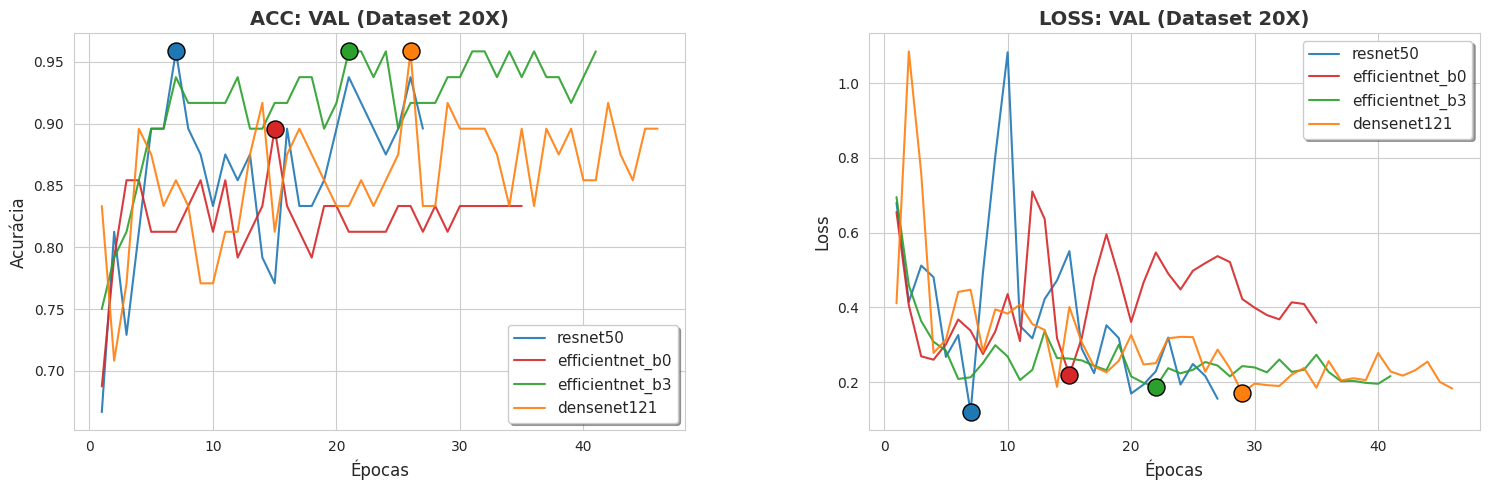



GRÁFICO DE COMPARAÇÃO DO DATASET 40X


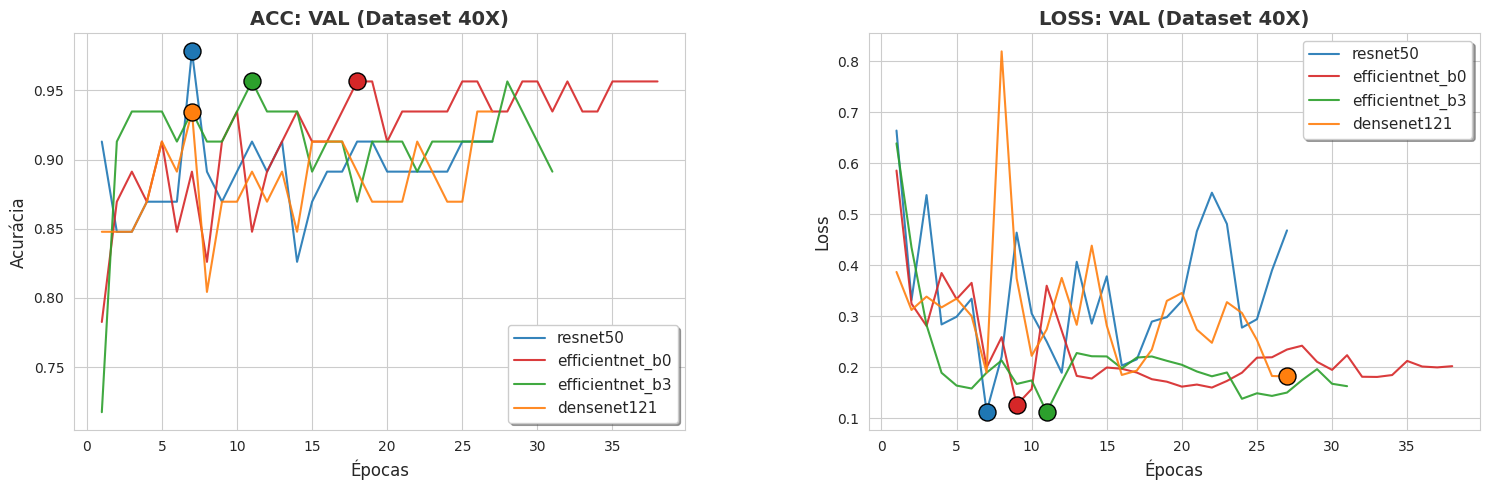

In [ ]:

def plot_line_chart_comparison(histories, title_suffix=""):
    sns.set_style("whitegrid") 
    colors = ['#1f77b4', '#d62728', '#2ca02c', '#ff7f0e', '#9467bd']
    
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    

    ax1 = axes[0]
    for i, (name, hist) in enumerate(histories.items()):
        val_acc = hist['val_acc']
        epochs = range(1, len(val_acc) + 1)

        ax1.plot(
            epochs,
            val_acc,
            label=name,
            color=colors[i % len(colors)],
            linewidth=1.5,
            linestyle='-',
            alpha=0.9
        )

        best_val = max(val_acc)
        best_epoch = val_acc.index(best_val) + 1

        ax1.scatter(
            best_epoch,
            best_val,
            s=150,
            c=colors[i],
            edgecolors='k',
            zorder=10
        )

    ax1.set_title(f'ACC: VAL {title_suffix}', fontsize=14, fontweight='bold', color='#333333')
    ax1.set_xlabel('Épocas', fontsize=12)
    ax1.set_ylabel('Acurácia', fontsize=12)
    ax1.legend(fontsize=11, frameon=True, fancybox=True, shadow=True)

    ax2 = axes[1]
    for i, (name, hist) in enumerate(histories.items()):
        val_loss = hist['val_loss']
        epochs = range(1, len(val_loss) + 1)

        ax2.plot(
            epochs,
            val_loss,
            label=name,
            color=colors[i % len(colors)],
            linewidth=1.5,
            linestyle='-',
            alpha=0.9
        )

        min_loss = min(val_loss)
        best_epoch_loss = val_loss.index(min_loss) + 1

        ax2.scatter(
            best_epoch_loss,
            min_loss,
            s=150,
            c=colors[i],
            edgecolors='k',
            zorder=10
        )

    ax2.set_title(f'LOSS: VAL {title_suffix}', fontsize=14, fontweight='bold', color='#333333')
    ax2.set_xlabel('Épocas', fontsize=12)
    ax2.set_ylabel('Loss', fontsize=12)
    ax2.legend(fontsize=11, frameon=True, fancybox=True, shadow=True)

    plt.tight_layout()
    plt.subplots_adjust(wspace=0.3)
    plt.show()


print(f"GRÁFICO DE COMPARAÇÃO DO DATASET 20X")
plot_line_chart_comparison(histories_20x, title_suffix="(Dataset 20X)")

print(f"\n\nGRÁFICO DE COMPARAÇÃO DO DATASET 40X")
plot_line_chart_comparison(histories_40x, title_suffix="(Dataset 40X)")

In [77]:
import os
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    accuracy_score,
    cohen_kappa_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

def evaluate_model_full(
    model,
    loader,
    model_name,
    dataset_name,
    class_names=['ACA', 'SCC', 'NOR'],
    save_dir="results_Rand"
):

    model.eval()

    y_true = []
    y_pred = []
    y_probs = []

    print(f"\nRELATÓRIO: {model_name.upper()} ({dataset_name})")

    with torch.no_grad():

        for inputs, labels in loader:

            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)

            outputs = torch.nan_to_num(
                outputs,
                nan=0.0,
                posinf=10.0,
                neginf=-10.0
            )

            _, preds = torch.max(outputs, 1)

            probs = F.softmax(outputs, dim=1)

            y_true.extend(labels.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())
            y_probs.extend(probs.cpu().numpy())

    y_probs = np.array(y_probs)

    y_probs = np.nan_to_num(
        y_probs,
        nan=1.0 / len(class_names)
    )

    acc = accuracy_score(y_true, y_pred)

    kappa = cohen_kappa_score(
        y_true,
        y_pred
    )

    try:

        labels_index = list(range(len(class_names)))

        roc_auc = roc_auc_score(
            y_true,
            y_probs,
            multi_class='ovr',
            average='macro',
            labels=labels_index
        )

    except Exception as e:

        print(f"ERRO ROC-AUC: {e}")

        print(
            f"(Shape y_probs: {y_probs.shape} | "
            f"Classes únicas em y_true: {np.unique(y_true)})"
        )

        roc_auc = 0.0

    print(
        f"➤ RESULTADO: "
        f"Accuracy: {acc:.4f} | "
        f"ROC-AUC: {roc_auc:.4f} | "
        f"Kappa: {kappa:.4f}\n"
    )

    print("RELATÓRIO DE CLASSIFICAÇÃO:")

    print(
        classification_report(
            y_true,
            y_pred,
            target_names=class_names,
            digits=4,
            zero_division=0
        )
    )

    cm = confusion_matrix(y_true, y_pred)

    print("\nMATRIZ DE CONFUSÃO:")
    print(cm)

    os.makedirs(save_dir, exist_ok=True)

    plt.figure(figsize=(6, 5))

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=class_names,
        yticklabels=class_names
    )

    plt.xlabel("Predito")
    plt.ylabel("Real")

    plt.title(f"Matriz de Confusão - {model_name} ({dataset_name})")

    plt.tight_layout()

    plt.savefig(
        f"{save_dir}/cm_{model_name}_{dataset_name}.png",
        dpi=300
    )

    plt.close()

    cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

    plt.figure(figsize=(6, 5))

    sns.heatmap(
        cm_norm,
        annot=True,
        fmt='.2f',
        cmap='Blues',
        xticklabels=class_names,
        yticklabels=class_names
    )

    plt.xlabel("Predito")
    plt.ylabel("Real")

    plt.title(f"Matriz Normalizada - {model_name} ({dataset_name})")

    plt.tight_layout()

    plt.savefig(
        f"{save_dir}/cm_norm_{model_name}_{dataset_name}.png",
        dpi=300
    )

    plt.close()

    print(f"✔ Matrizes salvas em: {save_dir}/")

    print("-" * 85)

    return acc, roc_auc, kappa, cm

In [78]:
print("RESULTADOS DA AVALIAÇÃO (DATASET 20X)")

for name, model in trained_models_20x.items():

    evaluate_model_full(
        model=model,
        loader=test_loader_20x,
        model_name=name,
        dataset_name="20x"
    )

RESULTADOS DA AVALIAÇÃO (DATASET 20X)

RELATÓRIO: RESNET50 (20x)
➤ RESULTADO: Accuracy: 0.9583 | ROC-AUC: 0.9902 | Kappa: 0.9358

RELATÓRIO DE CLASSIFICAÇÃO:
              precision    recall  f1-score   support

         ACA     1.0000    0.8889    0.9412        18
         SCC     1.0000    1.0000    1.0000        11
         NOR     0.9048    1.0000    0.9500        19

    accuracy                         0.9583        48
   macro avg     0.9683    0.9630    0.9637        48
weighted avg     0.9623    0.9583    0.9581        48


MATRIZ DE CONFUSÃO:
[[16  0  2]
 [ 0 11  0]
 [ 0  0 19]]
✔ Matrizes salvas em: results_Rand/
-------------------------------------------------------------------------------------

RELATÓRIO: EFFICIENTNET_B0 (20x)
➤ RESULTADO: Accuracy: 0.7917 | ROC-AUC: 0.9920 | Kappa: 0.6817

RELATÓRIO DE CLASSIFICAÇÃO:
              precision    recall  f1-score   support

         ACA     0.6429    1.0000    0.7826        18
         SCC     1.0000    1.0000    1.0000  

In [79]:
print("RESULTADOS DA AVALIAÇÃO (DATASET 40X)")

for name, model in trained_models_40x.items():

    evaluate_model_full(
        model=model,
        loader=test_loader_40x,
        model_name=name,
        dataset_name="40x"
    )

RESULTADOS DA AVALIAÇÃO (DATASET 40X)

RELATÓRIO: RESNET50 (40x)


/home/joyzinhw/.local/lib/python3.10/site-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


➤ RESULTADO: Accuracy: 0.9800 | ROC-AUC: 1.0000 | Kappa: 0.9695

RELATÓRIO DE CLASSIFICAÇÃO:
              precision    recall  f1-score   support

         ACA     0.9444    1.0000    0.9714        17
         SCC     1.0000    1.0000    1.0000        20
         NOR     1.0000    0.9231    0.9600        13

    accuracy                         0.9800        50
   macro avg     0.9815    0.9744    0.9771        50
weighted avg     0.9811    0.9800    0.9799        50


MATRIZ DE CONFUSÃO:
[[17  0  0]
 [ 0 20  0]
 [ 1  0 12]]
✔ Matrizes salvas em: results_Rand/
-------------------------------------------------------------------------------------

RELATÓRIO: EFFICIENTNET_B0 (40x)
➤ RESULTADO: Accuracy: 0.9800 | ROC-AUC: 1.0000 | Kappa: 0.9695

RELATÓRIO DE CLASSIFICAÇÃO:
              precision    recall  f1-score   support

         ACA     0.9444    1.0000    0.9714        17
         SCC     1.0000    1.0000    1.0000        20
         NOR     1.0000    0.9231    0.9600        13

 